<a href="https://colab.research.google.com/github/dipanwitad-create/NASSCOM_FDP_programme/blob/main/day2nasomU4_Linear_Algebra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

U4 — Linear Algebra: Lab
The language of data, models & transformations — vectors · matrices · tensors · norms · transformations · eigenvectors · rank

Day 2 · Phase B — Mathematical Foundations · Built from Module 1.3

objectives
By the end of this lab you will be able to:

Represent data as scalars, vectors, matrices and tensors, and do tensor ops (add, transpose, reshape)

Compute dot/cross products, L1/L2/L-infinity norms and cosine similarity

Work with matrix operations and special matrices (inverse, trace, symmetric, orthogonal)

Apply transformations (scaling, rotation) and plot the result

Find eigenvalues and eigenvectors and verify A v = lambda v

Solve a linear system, read its rank, and use cosine similarity on embeddings

how to use this lab
Each section has two kinds of cells:

Worked demo cells — run them top to bottom and read the comments to learn the pattern.

LAB EXERCISE cells (marked 🧪) — your turn. Replace each # YOUR CODE HERE with working code.

Run cells with Shift + Enter. Run the demos before attempting the exercises.

In [ ]:
# Core imports for the whole lab
import numpy as np
import numpy.linalg as la          # inv, norm, eig, solve, matrix_rank
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)   # tidy array printing
np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.0.2


In [ ]:
# -----------------------------------------------------------
# 🔹 1A. THE FOUR CONTAINERS
# -----------------------------------------------------------

scalar = np.array(5)                  # 0-D: a single number
vector = np.array([2, 5, 1])          # 1-D: a list of numbers
matrix = np.array([[1, 2], [3, 4]])   # 2-D: rows x columns
tensor = np.ones((3, 2, 2))           # n-D: a stack of matrices

# .ndim = number of dimensions, .shape = size along each dimension
for name, arr in [('scalar', scalar), ('vector', vector),
                  ('matrix', matrix), ('tensor', tensor)]:
    print(f'{name:7s} ndim={arr.ndim}  shape={arr.shape}')

scalar  ndim=0  shape=()
vector  ndim=1  shape=(3,)
matrix  ndim=2  shape=(2, 2)
tensor  ndim=3  shape=(3, 2, 2)


In [ ]:

# -----------------------------------------------------------
# 🔹 1B. TENSOR OPERATIONS: add, transpose, reshape
# -----------------------------------------------------------

A = np.arange(6).reshape(2, 3)   # shape (2, 3)
B = np.ones((2, 3), dtype=int)

print('A:\n', A)
print('A + B (element-wise add):\n', A + B)
print('A.T  (transpose -> shape', A.T.shape, '):\n', A.T)
print('A.reshape(3, 2):\n', A.reshape(3, 2))
print('A.flatten():', A.flatten())

A:
 [[0 1 2]
 [3 4 5]]
A + B (element-wise add):
 [[1 2 3]
 [4 5 6]]
A.T  (transpose -> shape (3, 2) ):
 [[0 3]
 [1 4]
 [2 5]]
A.reshape(3, 2):
 [[0 1]
 [2 3]
 [4 5]]
A.flatten(): [0 1 2 3 4 5]


In [ ]:
import numpy as np

T = np.arange(12).reshape(3, 4)
print('T:\n', T)

# 1. ndim and shape
print("Number of dimensions (ndim):", T.ndim)
print("Shape:", T.shape)

# 2. T + T
print("\nT + T:")
print(T + T)

# 3. Transpose and reshape
T_transpose = T.T
print("\nTranspose of T:")
print(T_transpose)
print("Transpose shape:", T_transpose.shape)

T_reshape = T.reshape(2, 6)
print("\nReshaped T (2,6):")
print(T_reshape)
print("Reshaped shape:", T_reshape.shape)
T_reshape = T.reshape(1, 12)
print("\nReshaped T (1,12):")
print(T_reshape)
print("Reshaped shape:", T_reshape.shape)

T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Number of dimensions (ndim): 2
Shape: (3, 4)

T + T:
[[ 0  2  4  6]
 [ 8 10 12 14]
 [16 18 20 22]]

Transpose of T:
[[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]
Transpose shape: (4, 3)

Reshaped T (2,6):
[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]
Reshaped shape: (2, 6)

Reshaped T (2,6):
[[ 0  1  2  3  4  5  6  7  8  9 10 11]]
Reshaped shape: (1, 12)


 LAB EXERCISE 1 — Tensor ops: add, transpose, reshape
Using the array T provided below:

Print its ndim and shape.
Add T to itself and print the result.
Transpose T and print the new shape, then reshape T into shape (2, 6).

In [ ]:
# -----------------------------------------------------------
# 🔹 2A. DOT & CROSS PRODUCTS
# -----------------------------------------------------------

a = np.array([1, 2, 3])
b = np.array([4, 0, 1])

# Dot product: sum of element-wise products -> measures alignment
print('a . b  (dot)   :', np.dot(a, b))      # 1*4 + 2*0 + 3*1 = 7

# Cross product: a new vector perpendicular to both (3-D only)
print('a x b  (cross) :', np.cross(a, b))

a . b  (dot)   : 7
a x b  (cross) : [ 2 11 -8]


In [ ]:
import numpy as np

# Cosine Similarity Function
def cosine_similarity(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

In [ ]:
pairs = [
    (np.array([1, 0, 1]), np.array([1, 0, 1])),    # pair 1
    (np.array([1, 2, 3]), np.array([3, 2, 1])),    # pair 2
    (np.array([2, 0, 0]), np.array([0, 5, 0])),    # pair 3
]

In [ ]:
for i, (u, v) in enumerate(pairs, start=1):
    # 1. L1 and L2 norm of u
    l1 = np.linalg.norm(u, 1)
    l2 = np.linalg.norm(u, 2)

    # 2. Cosine similarity of u and v
    cos_sim = cosine_similarity(u, v)

    print(f"Pair {i}:")
    print("u =", u)
    print("v =", v)
    print("L1 Norm of u =", l1)
    print("L2 Norm of u =", l2)
    print("Cosine Similarity =", round(cos_sim, 4))
    print()

# 3. Most similar pair = Pair 1
# Cosine Similarity = 1.0 (identical vectors)

Pair 1:
u = [1 0 1]
v = [1 0 1]
L1 Norm of u = 2.0
L2 Norm of u = 1.4142135623730951
Cosine Similarity = 1.0

Pair 2:
u = [1 2 3]
v = [3 2 1]
L1 Norm of u = 6.0
L2 Norm of u = 3.7416573867739413
Cosine Similarity = 0.7143

Pair 3:
u = [2 0 0]
v = [0 5 0]
L1 Norm of u = 2.0
L2 Norm of u = 2.0
Cosine Similarity = 0.0



In [ ]:
# -----------------------------------------------------------
# 🔹 3A. CORE MATRIX OPERATIONS
# -----------------------------------------------------------

A = np.array([[2., 1.],
              [1., 3.]])
B = np.array([[1., 0.],
              [4., 2.]])

print('A @ B (matrix multiply):\n', A @ B)
print('A.T   (transpose):\n', A.T)
print('inverse(A):\n', la.inv(A))
print('trace(A) = sum of diagonal:', np.trace(A))


A @ B (matrix multiply):
 [[ 6.  2.]
 [13.  6.]]
A.T   (transpose):
 [[2. 1.]
 [1. 3.]]
inverse(A):
 [[ 0.6 -0.2]
 [-0.2  0.4]]
trace(A) = sum of diagonal: 5.0


In [ ]:
# -----------------------------------------------------------
# 🔹 3B. SPECIAL MATRICES: identity, symmetric, orthogonal
# -----------------------------------------------------------

I = np.eye(2)                       # identity: 1s on the diagonal
print('Identity I:\n', I)
print('A @ inv(A) == I ?', np.allclose(A @ la.inv(A), I))

# Symmetric: A equals its own transpose
print('A symmetric?', np.allclose(A, A.T))

# Orthogonal: Q.T @ Q == I (a pure rotation/reflection)
theta = np.radians(30)
Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
print('Q orthogonal?', np.allclose(Q.T @ Q, I))

Identity I:
 [[1. 0.]
 [0. 1.]]
A @ inv(A) == I ? True
A symmetric? True
Q orthogonal? True


In [ ]:
import numpy as np

M = np.array([[4., 2.],
              [2., 3.]])

P = np.array([[0., -1.],
              [1.,  0.]])   # 90-degree rotation

# 1. Inverse and Trace of M
M_inv = np.linalg.inv(M)
trace_M = np.trace(M)

print("Inverse of M:")
print(M_inv)

print("\nTrace of M:")
print(trace_M)

# 2. Verify M @ inv(M) = I
I = np.eye(2)

print("\nM @ inv(M):")
print(M @ M_inv)

print("\nIs M @ inv(M) equal to I?")
print(np.allclose(M @ M_inv, I))

# 3. Matrix Tests

# Symmetric: M = M^T
is_symmetric = np.allclose(M, M.T)

# Orthogonal: P^T P = I
is_orthogonal = np.allclose(P.T @ P, I)

print("\nIs M symmetric?")
print(is_symmetric)

print("\nIs P orthogonal?")
print(is_orthogonal)

Inverse of M:
[[ 0.375 -0.25 ]
 [-0.25   0.5  ]]

Trace of M:
7.0

M @ inv(M):
[[1. 0.]
 [0. 1.]]

Is M @ inv(M) equal to I?
True

Is M symmetric?
True

Is P orthogonal?
True


In [ ]:
# -----------------------------------------------------------
# 🔹 4A. BUILD TRANSFORMATION MATRICES
# -----------------------------------------------------------

# A unit square defined by its 4 corners (each column is a point)
square = np.array([[0, 1, 1, 0],
                   [0, 0, 1, 1]], dtype=float)

# Scaling matrix: stretch x by 1.5, y by 0.5
S = np.array([[1.5, 0.0],
              [0.0, 0.5]])

# Rotation matrix: rotate by 30 degrees
t = np.radians(30)
R = np.array([[np.cos(t), -np.sin(t)],
              [np.sin(t),  np.cos(t)]])

scaled  = S @ square      # apply scaling
rotated = R @ square      # apply rotation
print('Rotated corners:\n', rotated)

Rotated corners:
 [[ 0.     0.866  0.366 -0.5  ]
 [ 0.     0.5    1.366  0.866]]


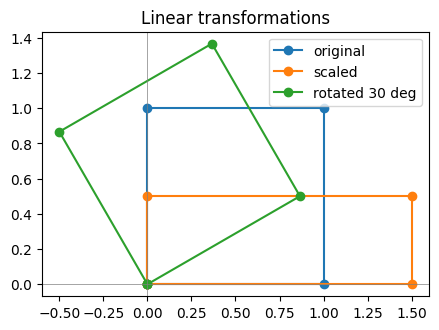

In [ ]:
# -----------------------------------------------------------
# 🔹 4B. PLOT ORIGINAL vs TRANSFORMED
# -----------------------------------------------------------

def close_loop(pts):
    # repeat the first point at the end so the polygon closes
    return np.hstack([pts, pts[:, :1]])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*close_loop(square),  marker='o', label='original')
ax.plot(*close_loop(scaled),  marker='o', label='scaled')
ax.plot(*close_loop(rotated), marker='o', label='rotated 30 deg')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title('Linear transformations')
plt.show()

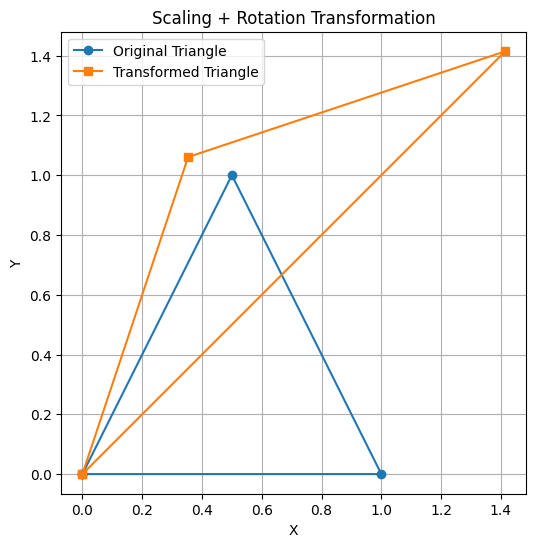

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Triangle vertices
tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])

# Function to close the shape for plotting
def close_loop(X):
    return np.hstack([X, X[:, :1]])

# 1. Scaling matrix (x*2, y*0.5)
S = np.array([[2, 0],
              [0, 0.5]])

# 2. Rotation matrix (45 degrees)
theta = np.radians(45)

R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])

# 3. Apply both transformations
# First Scale, then Rotate
tri_transformed = R @ (S @ tri)

# Close loops for plotting
tri_closed = close_loop(tri)
tri_transformed_closed = close_loop(tri_transformed)

# Plot
plt.figure(figsize=(6,6))

plt.plot(tri_closed[0], tri_closed[1],
         marker='o', label='Original Triangle')

plt.plot(tri_transformed_closed[0], tri_transformed_closed[1],
         marker='s', label='Transformed Triangle')

plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title('Scaling + Rotation Transformation')
plt.xlabel('X')
plt.ylabel('Y')

plt.show()

In [ ]:
# -----------------------------------------------------------
# 🔹 5A. COMPUTE EIGENVALUES & EIGENVECTORS
# -----------------------------------------------------------

A = np.array([[2., 0.],
              [0., 3.]])

vals, vecs = la.eig(A)     # vals = eigenvalues, vecs columns = eigenvectors
print('Eigenvalues  (lambda):', vals)
print('Eigenvectors (columns):\n', vecs)

Eigenvalues  (lambda): [2. 3.]
Eigenvectors (columns):
 [[1. 0.]
 [0. 1.]]


In [ ]:
# -----------------------------------------------------------
# 🔹 5B. VERIFY  A v = lambda v
# -----------------------------------------------------------

for i in range(len(vals)):
    v = vecs[:, i]                 # i-th eigenvector
    lhs = A @ v                    # A v
    rhs = vals[i] * v              # lambda v
    print(f'lambda={vals[i]:.1f}  A v == lambda v ?', np.allclose(lhs, rhs))

lambda=2.0  A v == lambda v ? True
lambda=3.0  A v == lambda v ? True


In [ ]:
import numpy as np
import numpy.linalg as la

C = np.array([[4., 1.],
              [2., 3.]])

# 1. Eigenvalues and Eigenvectors
eigenvalues, eigenvectors = la.eig(C)

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors:")
print(eigenvectors)

# 2. Print Eigenvalues
print("\nEigenvalues are:")
for val in eigenvalues:
    print(val)

# 3. Verify Cv = λv for the first eigenvector
v = eigenvectors[:, 0]      # First eigenvector
lam = eigenvalues[0]        # Corresponding eigenvalue

left_side = C @ v
right_side = lam * v

print("\nC @ v:")
print(left_side)

print("\nlambda * v:")
print(right_side)

print("\nVerification (Cv = λv):")
print(np.allclose(left_side, right_side))

Eigenvalues:
[5. 2.]

Eigenvectors:
[[ 0.707 -0.447]
 [ 0.707  0.894]]

Eigenvalues are:
5.0
2.0

C @ v:
[3.536 3.536]

lambda * v:
[3.536 3.536]

Verification (Cv = λv):
True


In [ ]:
# -----------------------------------------------------------
# 🔹 6A. SOLVE A 3x3 SYSTEM  A x = b
# -----------------------------------------------------------
import numpy as np

def cosine(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))


A = np.array([[ 2.,  1., -1.],
              [-3., -1.,  2.],
              [-2.,  1.,  2.]])
b = np.array([8., -11., -3.])

x = la.solve(A, b)
print('Solution x:', x)                    # [2, 3, -1]
print('Rank of A :', la.matrix_rank(A))     # 3 -> full rank
print('Full rank -> a unique solution exists')

Solution x: [ 2.  3. -1.]
Rank of A : 3
Full rank -> a unique solution exists


In [ ]:
# -----------------------------------------------------------
# 🔹 6B. RANK TELLS YOU SOLVABILITY
# -----------------------------------------------------------

# A rank-deficient matrix: row 3 = row 1 + row 2 (not independent)
D = np.array([[1., 2., 3.],
              [4., 5., 6.],
              [5., 7., 9.]])
print('Rank of D:', la.matrix_rank(D), '-> < 3, so rows are dependent')


Rank of D: 2 -> < 3, so rows are dependent


In [ ]:

# -----------------------------------------------------------
# 🔹 6C. COSINE SIMILARITY ON 'EMBEDDINGS'
# -----------------------------------------------------------

# Toy 4-D embeddings (in practice these come from a model)
king  = np.array([0.8, 0.6, 0.1, 0.2])
queen = np.array([0.7, 0.7, 0.1, 0.3])
apple = np.array([0.1, 0.0, 0.9, 0.8])

print('cosine(king, queen):', round(cosine(king, queen), 3))   # high
print('cosine(king, apple):', round(cosine(king, apple), 3))   # low

cosine(king, queen): 0.986
cosine(king, apple): 0.267


In [ ]:
import numpy as np

# Cosine Similarity Function
def cosine(u, v):
    return np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))

A2 = np.array([[3., 2.],
               [1., 4.]])
b2 = np.array([7., 9.])

cat = np.array([0.9, 0.8, 0.1])
dog = np.array([0.85, 0.7, 0.2])
car = np.array([0.1, 0.2, 0.95])

# 1. Solve A2 x = b2
x = np.linalg.solve(A2, b2)
print("Solution x:")
print(x)

# 2. Rank of A2
rank = np.linalg.matrix_rank(A2)
print("\nRank of A2:", rank)

# 3. Cosine Similarities
cat_dog = cosine(cat, dog)
cat_car = cosine(cat, car)

print("\nCosine(cat, dog):", round(cat_dog, 3))
print("Cosine(cat, car):", round(cat_car, 3))

if cat_dog > cat_car:
    print("cat and dog are more similar.")
else:
    print("cat and car are more similar.")

Solution x:
[1. 2.]

Rank of A2: 2

Cosine(cat, dog): 0.995
Cosine(cat, car): 0.293
cat and dog are more similar.
